# Road Network Analysis: Urabá Antioqueño and the Foothills of the Serranía del Abibe

The Urabá antioqueño is a strategic region in northwestern Colombia, composed of
 [the following municipalities](https://www.renovacionterritorio.gov.co/index.php/central-pdet/subregiones/uraba-antioqueno):

    Apartadó, Carepa, Chigorodó, Dabeiba, Mutatá, Necoclí, San Pedro de Urabá, Turbo.

The Urabá antioqueño is one of Colombia's most geographically and ecologically
diverse regions. It borders the Gulf of Urabá to the north, the foothills of the
Serranía del Abibe and the department of Chocó to the west, and the Darién jungle
to the south. This territorial configuration, crossed by large rivers and largely
covered by humid tropical forest, makes road infrastructure the primary means of
connection between its communities and supply centers.

The region faces a dual vulnerability. On the one hand, the persistence of armed
conflict has generated restrictions on mobility and recurring episodes of forced
confinement. On the other, the fragility of its road network, dominated by unpaved
secondary and tertiary roads exposed to heavy rainfall and landslides, leaves
numerous rural communities without timely access to healthcare, food supplies, and
emergency services.

In this setting, physical road connectivity is the primary lifeline for humanitarian
access. The structure of the network determines which communities can be reached, how
quickly aid can be delivered, and how failures propagate across the region. This
notebook focuses on the road system of the 8 municipalities of the Urabá antioqueño
and aims to:

1. Extract and simplify the OpenStreetMap (OSM) road network to obtain a tractable
   representation for spatial and network analysis.

2. Preserve connectivity and travel distances while reducing topological complexity
   through clustering-based graph simplification.

3. Identify critical edges whose removal or degradation would significantly reduce
   accessibility between supply points (source nodes) and affected communities
   (terminal nodes).

In [26]:
# For constructing the transport network and simplify it
from src.graph_construction import build_graph, simplify_graph 

# For selecting the supply points (source nodes) and affected communities (terminal nodes)
from src.flow_network import get_sources_targets

# For plotting the final network
from src.plot import plot_graph

In [27]:
# Create the graph from a list of cities
cities = [
    'Apartadó, Colombia', 
    'Carepa, Colombia',
    'Chigorodó, Colombia',
    'Dabeiba, Colombia',
    'Mutatá, Colombia',
    'Necoclí, Colombia',
    'San Pedro de Urabá, Colombia',
    'Turbo, Colombia',
]
gdf, G = build_graph(cities)

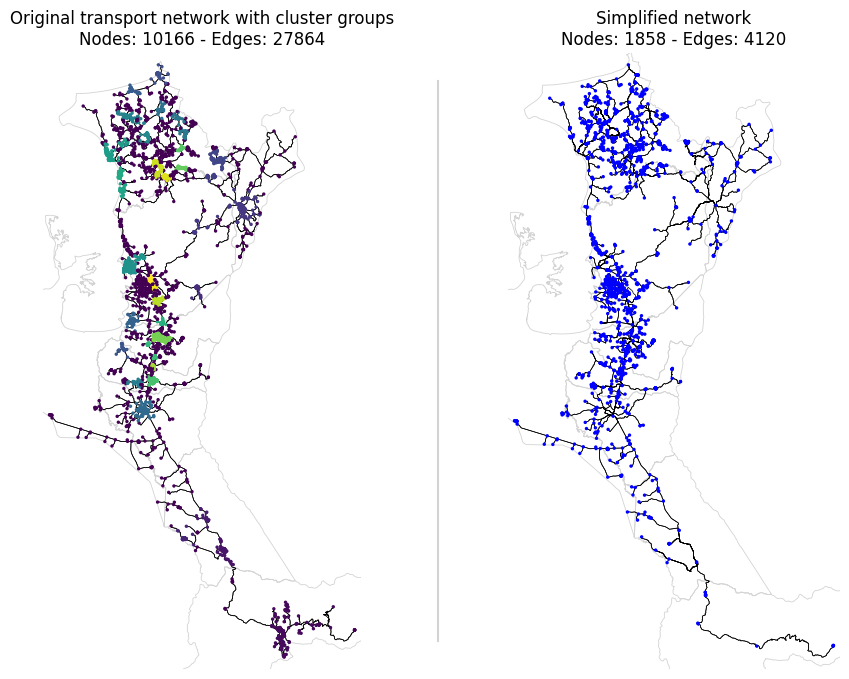

In [29]:
# Simplify the graph
G = simplify_graph(G, gdf, plot = True)

<Axes: title={'center': 'Catatumbo: simplified network with source and terminal nodes'}>

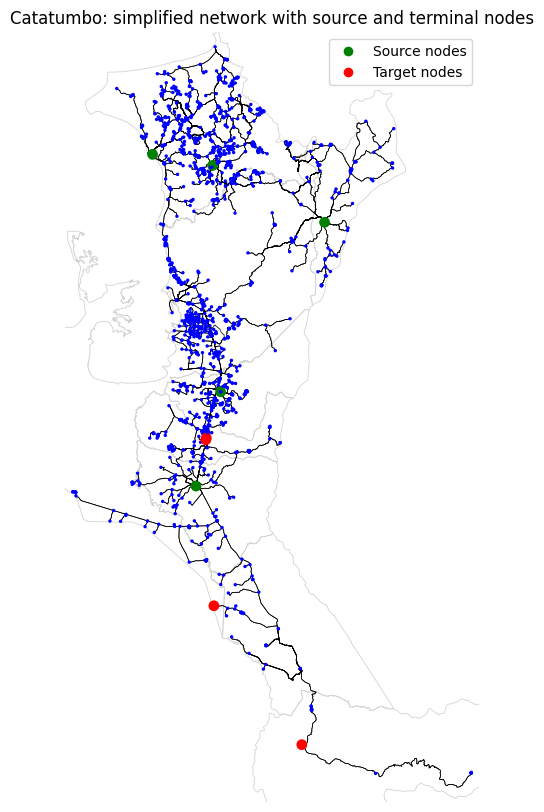

In [30]:
# Select 5 ources and 4 targets. 
# Sources are nodes with highest out-degree and target nodes are defined as the nodes with the lowest in-degree

G = get_sources_targets(G, n_sources=5, n_targets=4)
plot_graph(gdf, G, source_target = True, 
           title = "Catatumbo: simplified network with source and terminal nodes")